In [79]:
import torch
import numpy as np
from model import FCN
from data_utils import get_data_loaders
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

In [52]:
def linear_interpolation(device, model, checkpoint1, checkpoint2, loss_fn, dataloader, num_interp_points=10):

    # 初始化模型参数
    model1 = model(50).to(device)
    model2 = model(50).to(device)
    model1.load_state_dict(torch.load(checkpoint1, map_location=torch.device(device)))
    model2.load_state_dict(torch.load(checkpoint2, map_location=torch.device(device)))
    
    # 获取参数向量
    param_history1 = [p.clone().detach().numpy().flatten() for p in model1.parameters()]
    param_history2 = [p.clone().detach().numpy().flatten() for p in model2.parameters()]

    param_history1 = np.concatenate(param_history1)
    param_history2 = np.concatenate(param_history2)

    # 生成插值点
    alphas = np.linspace(0, 1, num_interp_points)
    losses = []

    # 数据加载
    inputs, targets = next(iter(dataloader))
    inputs, targets = inputs.to(device), targets.to(device)

    for alpha in alphas:
        interp_params = (1 - alpha) * param_history1 + alpha * param_history2

        # 将插值参数加载到模型中
        offset = 0
        model_interpolated = model(50).to(device)
        for p in model_interpolated.parameters():
            param_shape = p.shape
            param_num = np.prod(param_shape)
            p.data = torch.tensor(interp_params[offset:offset + param_num].reshape(param_shape), dtype=torch.float32)
            offset += param_num

        # 计算损失
        model_interpolated.eval()
        with torch.no_grad():
            outputs = model_interpolated(inputs)
            loss = loss_fn(outputs, targets).item()
            losses.append(loss)

    return alphas, losses


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, _ = get_data_loaders('MNIST', 100, 20, 1000)
inputs, targets = next(iter(train_loader))
inputs, targets = inputs.to(device), targets.to(device)

Using device: cpu


In [7]:
model = FCN(50).to(device)
criterion = torch.nn.CrossEntropyLoss()

In [64]:
batch_size = 100
learning_rate = 0.01
realization = 1
load_dir = f'bs{batch_size}_lr{learning_rate}_repeat{realization}'
checkpoint1 = f'../save_checkpoint_v2/bs100_lr0.1_repeat1/iteration_10.pt'
checkpoint2 = f'../save_checkpoint_v2/bs100_lr0.1_repeat20/iteration_10.pt'


In [65]:
alphas, losses = linear_interpolation(device, FCN, checkpoint1, checkpoint2, criterion, train_loader, num_interp_points=10)
plt.figure()
plt.plot(alphas, losses, marker='o')
plt.xlabel('Interpolation Coefficient α')
plt.ylabel('Loss')
plt.title('Interpolation Coefficient α vs. Loss')
plt.grid(True)
plt.show()

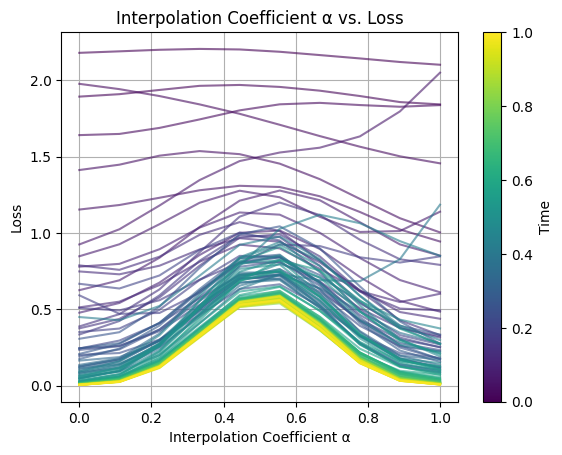

In [96]:
batch_size  100

# 迭代时间点
time_points = range(10, 1001, 10)

# 记录所有时间点的插值结果
interp_alpha_history = []
interp_loss_history = []

for t in time_points:
    checkpoint1 = f'../save_checkpoint_v2/bs100_lr0.1_repeat1/iteration_{t}.pt'
    checkpoint2 = f'../save_checkpoint_v2/bs100_lr0.1_repeat20/iteration_{t}.pt'
    alphas, losses = linear_interpolation(device, FCN, checkpoint1, checkpoint2, criterion, train_loader, num_interp_points=10)
    interp_alpha_history.append(alphas)
    interp_loss_history.append(losses)

# 转换为 NumPy 数组以便绘图
interp_alpha_history = np.array(interp_alpha_history)
interp_loss_history = np.array(interp_loss_history)

# 绘制所有时间点的插值结果
color_mapping = plt.cm.viridis(np.linspace(0, 1, len(time_points)))

plt.figure()
for t in range(interp_alpha_history.shape[0]):
    plt.plot(interp_alpha_history[t], interp_loss_history[t], color=color_mapping[t], alpha=0.6)

plt.xlabel('Interpolation Coefficient α')
plt.ylabel('Loss')
plt.title('Interpolation Coefficient α vs. Loss')
plt.grid(True)

cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
    ax=plt.gca(), label='Time')
#cbar.set_ticks(np.linspace(0, 100, 5))
#cbar.set_ticklabels(np.arange(0, 100, 5))
plt.show()